# Feasibility of trial sub-selection to match choice autocorrelation across belief-dim partitions

Companion data-exploration notebook for
[`claude_notes/trial_subselection_autocorrelation_matching.md`](../claude_notes/trial_subselection_autocorrelation_matching.md),
in the same spirit as `20260616_investigate_beh_for_choice_by_beliefs.ipynb`.

The note proposes sub-selecting **whole contiguous runs** of trials from the `Not in X Dim` / `Low`
partitions so their choice-label **run-length distribution matches the `In X Dim` reference**, in order to
equalize the session-permute shuffle baselines across partitions.

This notebook checks whether that procedure is actually feasible on the data, answering two questions
**per feature / session pair**:

1. **Are there enough trials?** Is the reference partition (`In X Dim`) large enough per choice class to
   support a decode, and do the source partitions have trials to draw from?
2. **Can the run-length distributions be matched?** Step 3 of the note samples *whole runs* from the source
   partition and only ever *truncates* longer runs (never pads). So a target run of length `L` can only be
   supplied by a source run of length `>= L`. We test whether the source partitions actually contain runs
   long enough to reproduce the reference's blocky structure.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import utils.behavioral_utils as behavioral_utils
from matplotlib import pyplot as plt
import seaborn as sns
from constants.behavioral_constants import *
from constants.decoding_constants import *
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [2]:
feats = []
for sub in ["SA", "BL"]:
    FEATS_PATH = f"/data/patrick_res/sessions/{sub}/feats_at_least_3blocks.pickle"
    sub_feats = pd.read_pickle(FEATS_PATH)
    sub_feats["subject"] = sub
    feats.append(sub_feats)
feats = pd.concat(feats)
pairs = feats.explode("sessions").reset_index(drop=True)
print(f"{len(pairs)} feature/session pairs across {feats.subject.nunique()} subjects")

300 feature/session pairs across 2 subjects


## Segment each partition into contiguous choice runs

Following Step 1 of the note: within a session, restrict to one partition's trials, order by `TrialNumber`,
and cut into **maximal runs of constant `Choice`**. A run ends when the choice label changes *or* when there
is a gap in `TrialNumber` larger than `GAP_TOL` (so runs respect real temporal contiguity).

`GAP_TOL = 1` is the strict reading: a run only continues across trials that are adjacent in `TrialNumber`.

In [3]:
GAP_TOL = 1
PARTITIONS = ["In X Dim", "Not in X Dim", "Low"]
CHOICES = ["Chose", "Not Chose"]

def segment_runs(beh, partition, gap_tol=GAP_TOL):
    sub = beh[beh.BeliefDimPartition == partition].sort_values("TrialNumber")
    if len(sub) == 0:
        return []
    tn = sub.TrialNumber.values
    ch = sub.Choice.values
    runs, start = [], 0
    for i in range(1, len(sub) + 1):
        brk = (i == len(sub)) or (ch[i] != ch[i - 1]) or (tn[i] - tn[i - 1] > gap_tol)
        if brk:
            runs.append({"choice": ch[start], "run_length": i - start, "start_trial": int(tn[start])})
            start = i
    return runs

def runs_for_pair(sub, session, feat, gap_tol=GAP_TOL):
    beh = behavioral_utils.get_valid_belief_beh_for_sub_sess(sub, session)
    beh = behavioral_utils.get_feat_choice_label(beh, feat)
    beh = behavioral_utils.get_belief_dim_partition(beh, feat, use_x=True)
    rows = []
    for p in PARTITIONS:
        for r in segment_runs(beh, p, gap_tol):
            r.update({"partition": p, "feat": feat, "session": str(session), "sub": sub})
            rows.append(r)
    return rows

In [4]:
allruns = []
for _, row in tqdm(pairs.iterrows(), total=len(pairs)):
    allruns.extend(runs_for_pair(row["subject"], row["sessions"], row["feat"]))
runs_df = pd.DataFrame(allruns)
print(f"{len(runs_df)} runs total")
runs_df.groupby(["partition", "choice"]).run_length.agg(["count", "sum", "max", "mean"])

100%|██████████| 300/300 [00:22<00:00, 13.34it/s]


122493 runs total


count    sum  max      mean
partition    choice                                
In X Dim     Chose       9358  22398   12  2.393460
             Not Chose  12209  50049   46  4.099353
Low          Chose      24495  34887   10  1.424250
             Not Chose  31843  93671   22  2.941651
Not in X Dim Chose      19836  28926   11  1.458258
             Not Chose  24752  81869   47  3.307571

The aggregate already shows the asymmetry the note describes: `In X Dim` has **fewer but longer** runs,
while `Not in X Dim` / `Low` have **many short** runs. That blocky structure is exactly what the matching
must reproduce in the source partitions.

## Q1 — Are there enough trials?

`In X Dim` is the reference (scarcest) partition and the limiting class within it sets the achievable decode
size. For each pair, compute the per-choice trial totals in `In X Dim` and take the minimum (the limiting
class). The decode pipeline elsewhere balances classes and uses thresholds around 3-5 trials per condition.

In X Dim limiting-class trial count per pair:
count    300.000000
mean      74.190000
std       26.143172
min       20.000000
25%       57.000000
50%       71.500000
75%       88.000000
max      167.000000
Name: limiting, dtype: float64
  pairs with limiting class >=  3 trials: 300/300 (100.0%)
  pairs with limiting class >=  5 trials: 300/300 (100.0%)
  pairs with limiting class >= 10 trials: 300/300 (100.0%)
  pairs with limiting class >= 20 trials: 300/300 (100.0%)


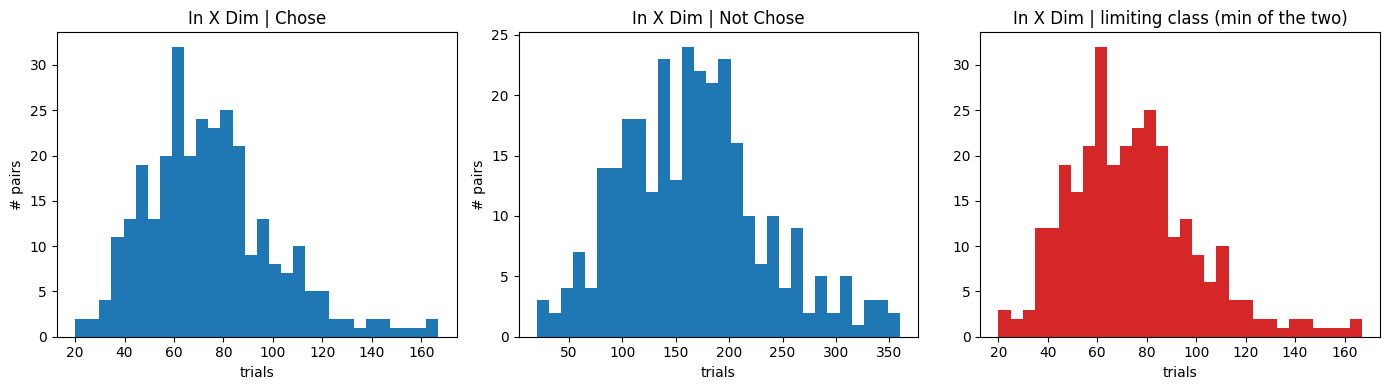

In [5]:
ix_counts = (runs_df[runs_df.partition == "In X Dim"]
             .groupby(["sub", "session", "feat", "choice"]).run_length.sum()
             .reset_index())
piv = ix_counts.pivot_table(index=["sub", "session", "feat"], columns="choice",
                            values="run_length", fill_value=0)
piv["limiting"] = piv[CHOICES].min(axis=1)

print("In X Dim limiting-class trial count per pair:")
print(piv["limiting"].describe())
for thr in [3, 5, 10, 20]:
    n = (piv["limiting"] >= thr).sum()
    print(f"  pairs with limiting class >= {thr:>2} trials: {n}/{len(piv)} ({n/len(piv):.1%})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, choice in zip(axes[:2], CHOICES):
    ax.hist(piv[choice], bins=30)
    ax.set_title(f"In X Dim | {choice}"); ax.set_xlabel("trials"); ax.set_ylabel("# pairs")
axes[2].hist(piv["limiting"], bins=30, color="C3")
axes[2].set_title("In X Dim | limiting class (min of the two)"); axes[2].set_xlabel("trials")
plt.tight_layout(); plt.show()

**Trials are not the bottleneck.** Every pair has a comfortable number of `In X Dim` trials per class
(min ~20, median ~70), and the source partitions are larger still. If the procedure fails, it is not for
lack of trials.

## Q2 — Can the run-length distributions be matched?

Per the note's Step 3 greedy assembly: walk the target (`In X Dim`) run-length histogram from longest to
shortest; each target run of length `L` must be supplied by a source run of length `>= L` (truncated down to
`L`). **Padding short runs up is forbidden.** So matching is feasible iff, sorting both run sets descending,
the `k`-th largest source run is `>= ` the `k`-th largest target run for every `k` (Hall's condition with
truncation).

We score each (pair, choice, source-partition):
- `feasible`: every target run can be supplied (full reproduction of the reference run-length histogram),
- `frac_trials_matched`: fraction of reference trials supplied by whole-run matching before the source runs
  out of long-enough runs.

In [6]:
def match_feasibility(target_lengths, source_lengths):
    T = sorted(target_lengths, reverse=True)
    S = sorted(source_lengths, reverse=True)
    n_t, N_t = len(T), sum(T)
    si = matched = trials_supplied = unmatched_runs = unmatched_trials = 0
    for L in T:
        if si < len(S) and S[si] >= L:        # truncate this source run down to L
            matched += 1; trials_supplied += L; si += 1
        else:
            unmatched_runs += 1; unmatched_trials += L
    return {
        "n_target_runs": n_t, "n_source_runs": len(S), "N_target": N_t,
        "matched_runs": matched, "unmatched_runs": unmatched_runs,
        "unmatched_trials": unmatched_trials,
        "frac_trials_matched": trials_supplied / N_t if N_t else np.nan,
        "feasible": unmatched_runs == 0,
        "target_max": max(T) if T else 0, "source_max": max(S) if S else 0,
    }

recs = []
for (sub, sess, feat), g in runs_df.groupby(["sub", "session", "feat"]):
    for choice in CHOICES:
        ref = g[(g.partition == "In X Dim") & (g.choice == choice)].run_length.tolist()
        if len(ref) == 0:
            continue
        for srcp in ["Not in X Dim", "Low"]:
            src = g[(g.partition == srcp) & (g.choice == choice)].run_length.tolist()
            m = match_feasibility(ref, src)
            m.update({"sub": sub, "session": sess, "feat": feat, "choice": choice, "source": srcp})
            recs.append(m)
feas = pd.DataFrame(recs)
feas["source_too_short"] = feas.source_max < feas.target_max

summary = feas.groupby(["source", "choice"]).agg(
    frac_pairs_feasible=("feasible", "mean"),
    mean_frac_trials_matched=("frac_trials_matched", "mean"),
    frac_pairs_source_too_short=("source_too_short", "mean"),
    mean_target_max_run=("target_max", "mean"),
    mean_source_max_run=("source_max", "mean"),
)
summary

frac_pairs_feasible  mean_frac_trials_matched  \
source       choice                                                     
Low          Chose                 0.000000                  0.534054   
             Not Chose             0.063333                  0.687145   
Not in X Dim Chose                 0.000000                  0.513795   
             Not Chose             0.163333                  0.727206   

                        frac_pairs_source_too_short  mean_target_max_run  \
source       choice                                                        
Low          Chose                         0.950000                 8.82   
             Not Chose                     0.846667                19.18   
Not in X Dim Chose                         0.966667                 8.82   
             Not Chose                     0.603333                19.18   

                        mean_source_max_run  
source       choice                          
Low          Chose                 5.016667  
             Not Chose            13.043333  
Not in X Dim Chose                 4.840000  
             Not Chose            16.806667

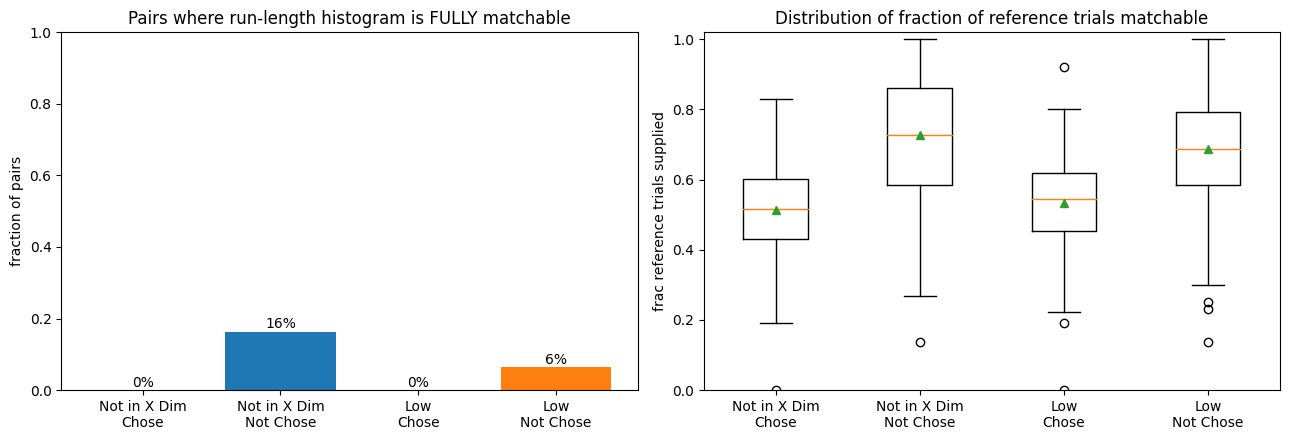

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = [("Not in X Dim", "Chose"), ("Not in X Dim", "Not Chose"),
         ("Low", "Chose"), ("Low", "Not Chose")]
labels = [f"{s}\n{c}" for s, c in order]

vals = [feas[(feas.source == s) & (feas.choice == c)].feasible.mean() for s, c in order]
axes[0].bar(labels, vals, color=["C0", "C0", "C1", "C1"])
axes[0].set_ylim(0, 1); axes[0].set_ylabel("fraction of pairs")
axes[0].set_title("Pairs where run-length histogram is FULLY matchable")
for i, v in enumerate(vals): axes[0].text(i, v + 0.01, f"{v:.0%}", ha="center")

axes[1].set_title("Distribution of fraction of reference trials matchable")
data = [feas[(feas.source == s) & (feas.choice == c)].frac_trials_matched.values for s, c in order]
axes[1].boxplot(data, labels=labels, showmeans=True)
axes[1].set_ylim(0, 1.02); axes[1].set_ylabel("frac reference trials supplied")
plt.tight_layout(); plt.show()

### Where does matching fail? Matched vs unmatched target runs by length

Pool all reference (`In X Dim`) target runs and mark which could be supplied by the source partition. The
unmatched runs are precisely the **long** ones — the blocks that generate the elevated autocorrelation the
procedure is meant to equalize.

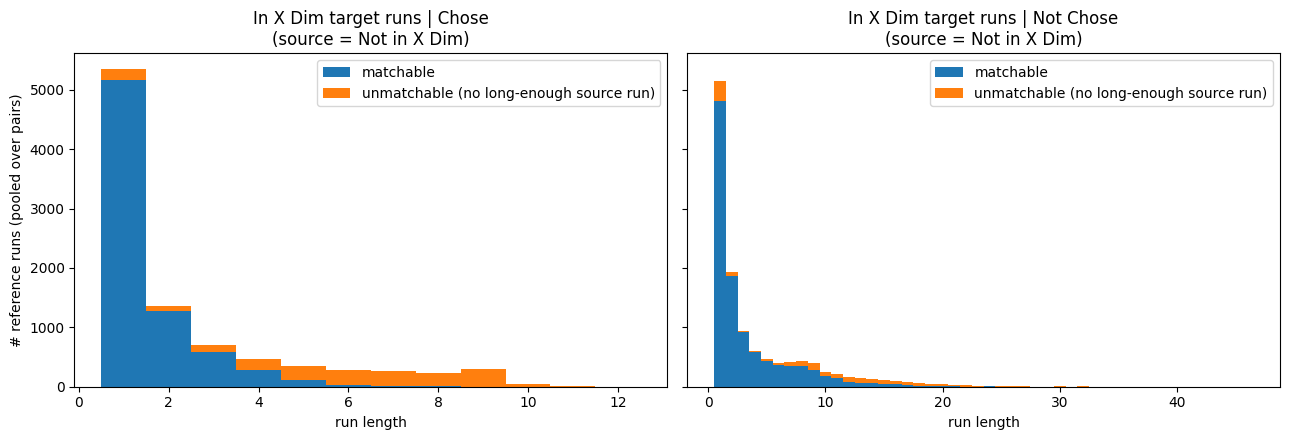

In [8]:
def matched_mask_by_length(source="Not in X Dim", choice="Chose"):
    lengths_matched, lengths_unmatched = [], []
    for (sub, sess, feat), g in runs_df.groupby(["sub", "session", "feat"]):
        T = sorted(g[(g.partition == "In X Dim") & (g.choice == choice)].run_length.tolist(), reverse=True)
        S = sorted(g[(g.partition == source) & (g.choice == choice)].run_length.tolist(), reverse=True)
        si = 0
        for L in T:
            if si < len(S) and S[si] >= L:
                lengths_matched.append(L); si += 1
            else:
                lengths_unmatched.append(L)
    return np.array(lengths_matched), np.array(lengths_unmatched)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, choice in zip(axes, CHOICES):
    m, u = matched_mask_by_length("Not in X Dim", choice)
    mx = max(m.max() if len(m) else 1, u.max() if len(u) else 1)
    bins = np.arange(0.5, mx + 1.5, 1)
    ax.hist([m, u], bins=bins, stacked=True, label=["matchable", "unmatchable (no long-enough source run)"])
    ax.set_title(f"In X Dim target runs | {choice}\n(source = Not in X Dim)")
    ax.set_xlabel("run length"); ax.legend()
axes[0].set_ylabel("# reference runs (pooled over pairs)")
plt.tight_layout(); plt.show()

## Example session: raster + run-length distributions

Mirrors the raster in `20260616_investigate_beh_for_choice_by_beliefs.ipynb`, for one feature/session, plus
the run-length histograms that the matching would have to reconcile.

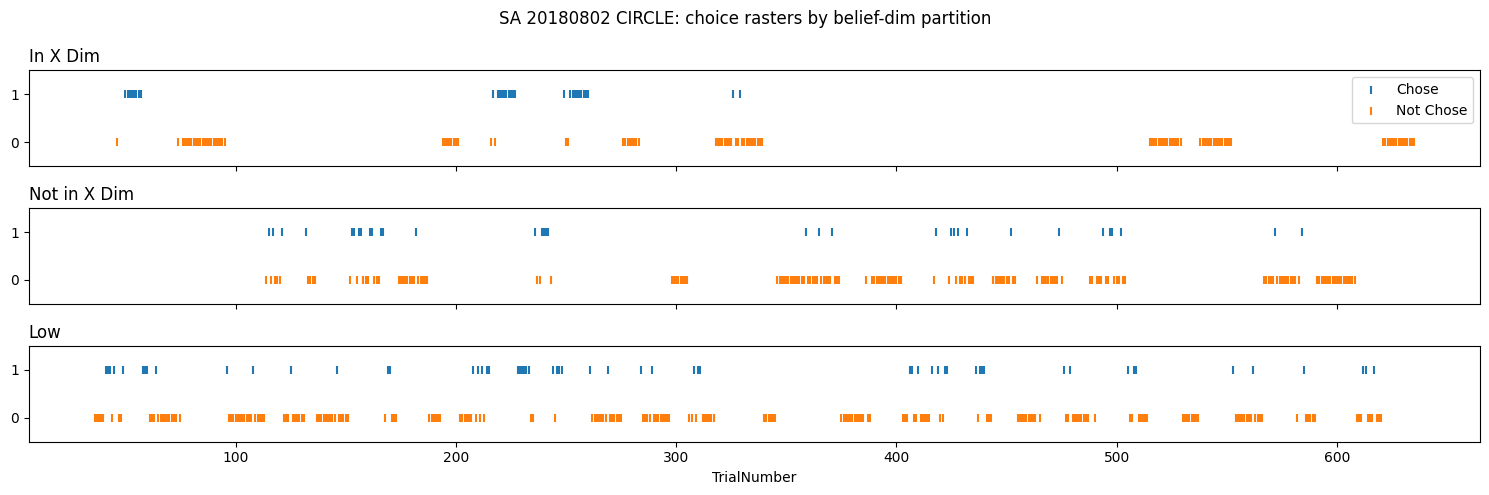

In [9]:
ex_sub, ex_sess, ex_feat = "SA", "20180802", "CIRCLE"
beh = behavioral_utils.get_valid_belief_beh_for_sub_sess(ex_sub, ex_sess)
beh = behavioral_utils.get_feat_choice_label(beh, ex_feat)
beh = behavioral_utils.get_belief_dim_partition(beh, ex_feat, use_x=True)
beh_v = beh[beh.TrialNumber < beh.TrialNumber.min() + 600]

fig, axs = plt.subplots(3, 1, figsize=(15, 5), sharex=True)
for ax, part in zip(axs, PARTITIONS):
    sub_p = beh_v[beh_v.BeliefDimPartition == part]
    chose = sub_p[sub_p.Choice == "Chose"]
    notc = sub_p[sub_p.Choice == "Not Chose"]
    ax.scatter(chose.TrialNumber, [1] * len(chose), marker="|", label="Chose")
    ax.scatter(notc.TrialNumber, [0] * len(notc), marker="|", label="Not Chose")
    ax.set_title(f"{part}", loc="left"); ax.set_yticks([0, 1]); ax.set_ylim(-0.5, 1.5)
axs[0].legend(loc="upper right"); axs[-1].set_xlabel("TrialNumber")
fig.suptitle(f"{ex_sub} {ex_sess} {ex_feat}: choice rasters by belief-dim partition")
plt.tight_layout(); plt.show()

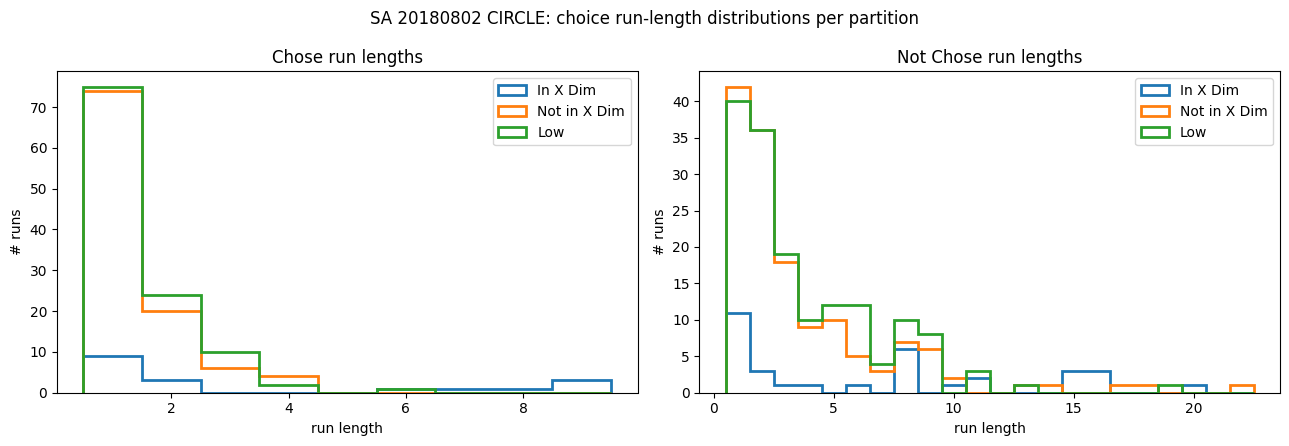

In [10]:
g = runs_df[(runs_df["sub"] == ex_sub) & (runs_df.session == ex_sess) & (runs_df.feat == ex_feat)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, choice in zip(axes, CHOICES):
    mx = g[g.choice == choice].run_length.max()
    bins = np.arange(0.5, mx + 1.5, 1)
    for part in PARTITIONS:
        d = g[(g.partition == part) & (g.choice == choice)].run_length
        ax.hist(d, bins=bins, histtype="step", linewidth=2, label=part)
    ax.set_title(f"{choice} run lengths"); ax.set_xlabel("run length"); ax.set_ylabel("# runs")
    ax.legend()
fig.suptitle(f"{ex_sub} {ex_sess} {ex_feat}: choice run-length distributions per partition")
plt.tight_layout(); plt.show()

## Conclusion

- **Q1 (enough trials): yes.** Every feature/session pair has ample trials in the reference `In X Dim`
  partition (limiting class median ~70, min ~20), and the source partitions are larger. Trial count is not
  the constraint.

- **Q2 (can run-length distributions be matched): essentially no.** Full reproduction of the `In X Dim`
  run-length histogram is achievable in **0% of pairs for `Chose`** and only a small fraction for
  `Not Chose`. On average only roughly half of the reference `Chose` trials can be supplied by whole-run
  matching. The reason is structural and is exactly the note's own caveat ("you cannot recreate blocky
  structure by randomly thinning trials"): in ~95-97% of pairs the longest `Chose` run available in
  `Not in X Dim` / `Low` is *shorter* than the longest `In X Dim` run, so truncation cannot manufacture the
  long blocks, and the unmatched runs are precisely the long, high-autocorrelation ones the procedure exists
  to equalize.

**Takeaway.** The run-matched sub-selection is not feasible as a primary fix on this data — the source
partitions simply lack long enough runs to reproduce the reference's blocky structure, and even partial
matching systematically discards the long runs that drive the autocorrelation. This supports the note's
recommendation to make **neural drift removal** the primary, trial-preserving fix and to treat sub-selection,
if used at all, only as a limited confirmatory analysis.

# Alternative subselection: match in the *whitening* direction

The conclusion above is that the note's procedure (method A: thin the dispersed partitions *up* to the blocky
`In X Dim` reference) is infeasible — the source partitions lack runs long enough to reproduce the reference's
blocky structure.

This section probes the **opposite direction**, motivated by a frequency-domain view of the problem: each
partition's choice sequence has its own autocorrelation "shape", and we ask whether one partition can be
subsampled so its shape matches another's. We

1. characterize the autocorrelation "shape" the matching must reconcile,
2. show that subsampling can only ever *whiten* a spectrum, so the feasible reference is the **dispersed**
   partition (method B: thin `In X Dim` *down* to `Not in X Dim`), and
3. quantify how many trials remain for the decoder after this matching.

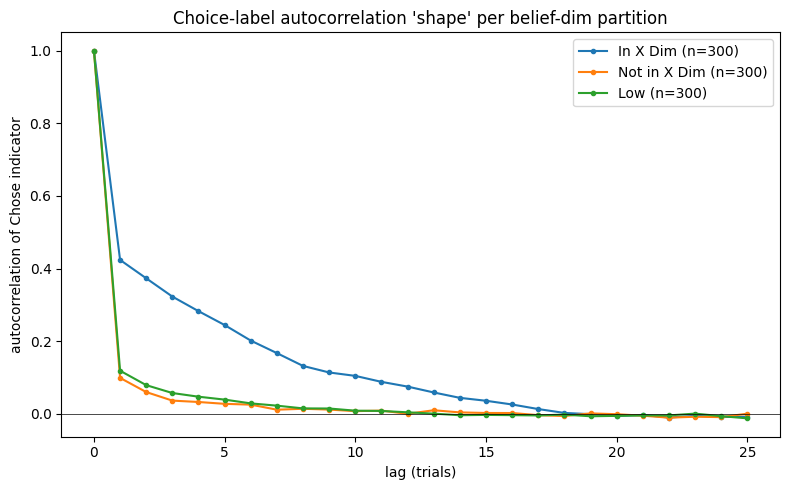

mean ACF at selected lags:
  In X Dim      lag1=0.424 lag3=0.323 lag5=0.244 lag10=0.104
  Not in X Dim  lag1=0.099 lag3=0.036 lag5=0.027 lag10=0.007
  Low           lag1=0.119 lag3=0.057 lag5=0.039 lag10=0.008


In [11]:
# The choice-label autocorrelation "shape" per partition. The binary `Chose` indicator is
# reconstructed in trial order from the segmented runs; we average per-(session,feat) ACFs
# within each partition. This is the lag-domain view of the run-length distributions above.

import collections

def acf_binary(x, maxlag=25):
    x = np.asarray(x, float); x = x - x.mean()
    n = len(x); v = np.dot(x, x)
    if v == 0 or n < maxlag + 1:
        return None
    return np.array([np.dot(x[:n - k], x[k:]) / v for k in range(maxlag + 1)])

MAXLAG = 25
acc = collections.defaultdict(list)
for (sub, sess, feat), g in runs_df.groupby(["sub", "session", "feat"]):
    for p in PARTITIONS:
        gp = g[g.partition == p].sort_values("start_trial")
        if len(gp) < 5:
            continue
        seq = []
        for _, r in gp.iterrows():
            seq += [1 if r.choice == "Chose" else 0] * int(r.run_length)
        a = acf_binary(seq, MAXLAG)
        if a is not None:
            acc[p].append(a)

fig, ax = plt.subplots(figsize=(8, 5))
for p in PARTITIONS:
    M = np.nanmean(np.vstack(acc[p]), axis=0)
    ax.plot(range(MAXLAG + 1), M, marker="o", ms=3, label=f"{p} (n={len(acc[p])})")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag (trials)"); ax.set_ylabel("autocorrelation of Chose indicator")
ax.set_title("Choice-label autocorrelation 'shape' per belief-dim partition")
ax.legend(); plt.tight_layout(); plt.show()

print("mean ACF at selected lags:")
for p in PARTITIONS:
    M = np.nanmean(np.vstack(acc[p]), axis=0)
    print(f"  {p:13s} lag1={M[1]:.3f} lag3={M[3]:.3f} lag5={M[5]:.3f} lag10={M[10]:.3f}")

### Direction matters: subsampling can only *whiten* the spectrum

The autocorrelation above is the choice sequence's "shape" in the lag (frequency) domain: `In X Dim` carries
real low-frequency power (slow, blocky structure), the others are nearly white. **Removing trials can only
fragment runs** — it moves power from low frequency to high (whitens the spectrum); it can never create the
longer runs / low-frequency power that aren't already present.

So matching by subsampling is feasible in **one direction only**: you can thin a partition *down* to a flatter
(more dispersed) target, never *up* to a blockier one. Method A picked the blocky `In X Dim` as the reference
— the impossible direction, hence its 0% feasibility above. The feasible move is the reverse: take the
**dispersed** `Not in X Dim` as the reference shape and thin `In X Dim`'s long runs down to it.

           frac_kept_mean  frac_kept_min  kept_trials_median
choice                                                      
Chose                0.48           0.19                34.0
Not Chose            0.46           0.17                72.0


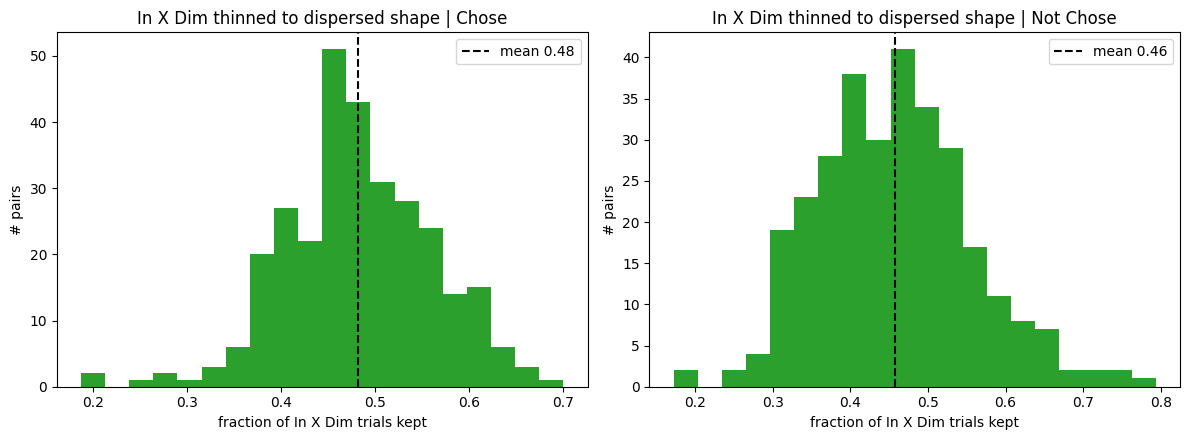

In [12]:
# Method B: thin `In X Dim` DOWN to the dispersed `Not in X Dim` run-length shape.
# NOTE on mechanism: subsetting trials canNOT split one run into several -- the kept trials
# of a single same-choice run stay contiguous in decode order, so they remain ONE run. It can
# only SHORTEN a run. So each maximal same-choice In X Dim run of length S is shortened to
# min(draw, S) with draw ~ the dispersed target run-length distribution for that choice.
# (Removing a whole run would instead MERGE its neighbours into a longer run, the wrong way.)
# #runs is preserved; runs get shorter -> the kept sequence whitens.

targets = {}
for choice in CHOICES:
    vc = (runs_df[(runs_df.partition == "Not in X Dim") & (runs_df.choice == choice)]
          .run_length.value_counts(normalize=True).sort_index())
    targets[choice] = (vc.index.values.astype(int), vc.values / vc.values.sum())

def thin_in_x_dim(g, rng):
    """Return (thinned Chose-indicator sequence, kept-trial counts per choice)."""
    runs = g[g.partition == "In X Dim"].sort_values("start_trial")
    seq = []; kept = {"Chose": 0, "Not Chose": 0}
    for _, r in runs.iterrows():
        S = int(r.run_length); ch = r.choice
        tlen, tprob = targets[ch]
        L = min(int(rng.choice(tlen, p=tprob)), S)   # shorten this run; never lengthen/split
        kept[ch] += L
        seq += [1 if ch == "Chose" else 0] * L
    return seq, kept

rng = np.random.default_rng(0)
rev = []
acc["In X Dim Thinned"] = []                          # feed the thinned ACF into the same store
for (sub, session, feat), g in runs_df.groupby(["sub", "session", "feat"]):
    if not (g.partition == "In X Dim").any():
        continue
    seq, kept = thin_in_x_dim(g, rng)
    a = acf_binary(seq, MAXLAG)
    if a is not None:
        acc["In X Dim Thinned"].append(a)
    for ch in CHOICES:
        orig = int(g[(g.partition == "In X Dim") & (g.choice == ch)].run_length.sum())
        rev.append({"sub": sub, "session": session, "feat": feat, "choice": ch,
                    "kept_trials": kept[ch], "orig_trials": orig,
                    "frac_kept": kept[ch] / orig if orig else np.nan})
rev = pd.DataFrame(rev)

print(rev.groupby("choice").agg(frac_kept_mean=("frac_kept", "mean"),
                                frac_kept_min=("frac_kept", "min"),
                                kept_trials_median=("kept_trials", "median")).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, choice in zip(axes, CHOICES):
    dd = rev[rev.choice == choice]
    ax.hist(dd.frac_kept, bins=20, color="C2")
    ax.axvline(dd.frac_kept.mean(), color="k", ls="--", label=f"mean {dd.frac_kept.mean():.2f}")
    ax.set_title(f"In X Dim thinned to dispersed shape | {choice}")
    ax.set_xlabel("fraction of In X Dim trials kept"); ax.set_ylabel("# pairs"); ax.legend()
plt.tight_layout(); plt.show()

### Does thinning move `In X Dim`'s autocorrelation onto the others?

This is the key check: overlay the **thinned** `In X Dim` choice-label ACF on the three original partitions.
The thing that drives the elevated shuffle baseline is the **low-frequency / long-lag** content (it is what
couples to slow neural drift). After thinning, `In X Dim`'s slowly-decaying tail (lag5≈0.24, lag10≈0.10)
collapses to ≈0 at lags ≥ 2 — i.e. **at or below** the dispersed `Not in X Dim` / `Low` partitions.

The thinned curve dips slightly *negative* at lag 1 (mild over-alternation, because long `Not Chose` runs are
shortened and interleaved with length-1 `Chose` runs). That is purely **high-frequency** structure and does
not couple to slow drift, so it is harmless for the baseline-equalization goal — if anything the thinned
sequence is *more* whitened than the dispersed reference at the low frequencies that matter.

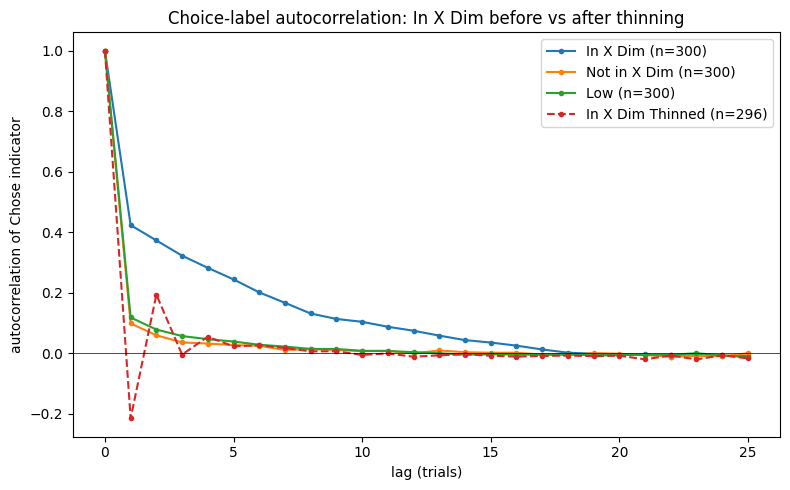

mean ACF at selected lags:
  In X Dim          lag1=+0.424 lag3=+0.323 lag5=+0.244 lag10=+0.104
  In X Dim Thinned  lag1=-0.215 lag3=-0.004 lag5=+0.023 lag10=-0.005
  Not in X Dim      lag1=+0.099 lag3=+0.036 lag5=+0.027 lag10=+0.007
  Low               lag1=+0.119 lag3=+0.057 lag5=+0.039 lag10=+0.008


In [13]:
# Does thinning actually whiten? Overlay the thinned `In X Dim` ACF on the original partitions.
fig, ax = plt.subplots(figsize=(8, 5))
styles = {"In X Dim": dict(color="C0"), "Not in X Dim": dict(color="C1"),
          "Low": dict(color="C2"), "In X Dim Thinned": dict(color="C3", ls="--")}
for p in ["In X Dim", "Not in X Dim", "Low", "In X Dim Thinned"]:
    M = np.nanmean(np.vstack(acc[p]), axis=0)
    ax.plot(range(MAXLAG + 1), M, marker="o", ms=3, label=f"{p} (n={len(acc[p])})", **styles[p])
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag (trials)"); ax.set_ylabel("autocorrelation of Chose indicator")
ax.set_title("Choice-label autocorrelation: In X Dim before vs after thinning")
ax.legend(); plt.tight_layout(); plt.show()

print("mean ACF at selected lags:")
for p in ["In X Dim", "In X Dim Thinned", "Not in X Dim", "Low"]:
    M = np.nanmean(np.vstack(acc[p]), axis=0)
    print(f"  {p:17s} lag1={M[1]:+.3f} lag3={M[3]:+.3f} lag5={M[5]:+.3f} lag10={M[10]:+.3f}")

### Example session: rasters including `In X Dim Thinned`

The same single-session raster as above, with a fourth row for the `In X Dim` trials kept by method B (each run
shortened to a draw from the dispersed target). The long `Chose` blocks in `In X Dim` are truncated to short
fragments — the run-length reduction that whitens the decode-order sequence. Note the kept trials remain at
their original `TrialNumber` positions (subselection shortens runs; it does not move trials), so this is the
serial-structure view, complementary to the aggregate ACF above.

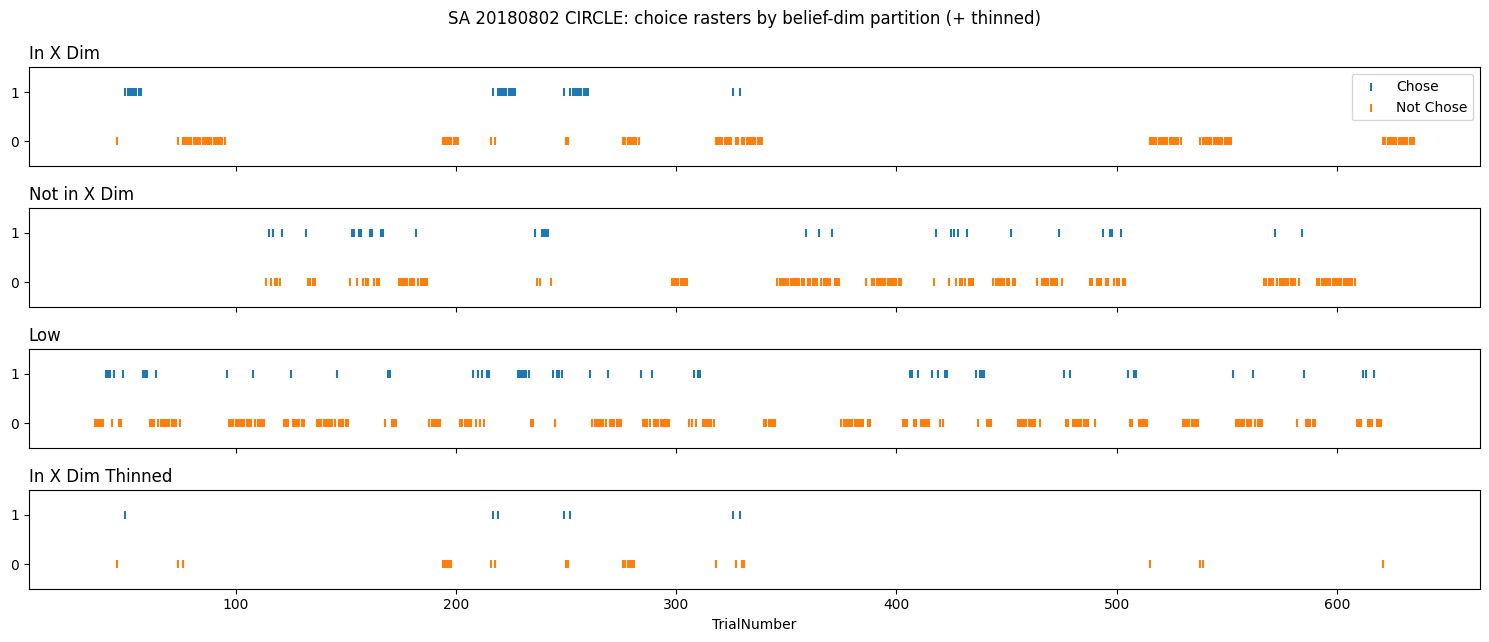

In [14]:
# Example-session raster (same session/feature as the earlier one) with a 4th row showing the
# `In X Dim` trials that SURVIVE method B, plotted at their original TrialNumber positions.
ex_sub, ex_sess, ex_feat = "SA", "20180802", "CIRCLE"
beh = behavioral_utils.get_valid_belief_beh_for_sub_sess(ex_sub, ex_sess)
beh = behavioral_utils.get_feat_choice_label(beh, ex_feat)
beh = behavioral_utils.get_belief_dim_partition(beh, ex_feat, use_x=True)

def thin_in_x_dim_trials(beh, targets, rng, gap_tol=GAP_TOL):
    """Which In X Dim TrialNumbers does method B keep? Segment into runs, shorten each run of
    length S to its first min(draw, S) trials (draw ~ dispersed target for that choice)."""
    sub = beh[beh.BeliefDimPartition == "In X Dim"].sort_values("TrialNumber")
    tn = sub.TrialNumber.values; ch = sub.Choice.values
    kept = []; start = 0
    for i in range(1, len(sub) + 1):
        if (i == len(sub)) or (ch[i] != ch[i - 1]) or (tn[i] - tn[i - 1] > gap_tol):
            S = i - start; tlen, tprob = targets[ch[start]]
            L = min(int(rng.choice(tlen, p=tprob)), S)
            kept.extend(tn[start:start + L])             # keep the first L trials of the run
            start = i
    return set(kept)

rng = np.random.default_rng(0)
kept_tn = thin_in_x_dim_trials(beh, targets, rng)

beh_v = beh[beh.TrialNumber < beh.TrialNumber.min() + 600]
rows = [("In X Dim",         beh_v[beh_v.BeliefDimPartition == "In X Dim"]),
        ("Not in X Dim",     beh_v[beh_v.BeliefDimPartition == "Not in X Dim"]),
        ("Low",              beh_v[beh_v.BeliefDimPartition == "Low"]),
        ("In X Dim Thinned", beh_v[(beh_v.BeliefDimPartition == "In X Dim") &
                                   (beh_v.TrialNumber.isin(kept_tn))])]
fig, axs = plt.subplots(4, 1, figsize=(15, 6.5), sharex=True)
for ax, (name, sub_p) in zip(axs, rows):
    chose = sub_p[sub_p.Choice == "Chose"]
    notc = sub_p[sub_p.Choice == "Not Chose"]
    ax.scatter(chose.TrialNumber, [1] * len(chose), marker="|", label="Chose")
    ax.scatter(notc.TrialNumber, [0] * len(notc), marker="|", label="Not Chose")
    ax.set_title(name, loc="left"); ax.set_yticks([0, 1]); ax.set_ylim(-0.5, 1.5)
axs[0].legend(loc="upper right"); axs[-1].set_xlabel("TrialNumber")
fig.suptitle(f"{ex_sub} {ex_sess} {ex_feat}: choice rasters by belief-dim partition (+ thinned)")
plt.tight_layout(); plt.show()

### How many trials survive for the decoder?

The matching is only useful if enough trials remain to decode. Method B thins **only** `In X Dim` (the
dispersed partitions are themselves the target shape, so they keep all their trials and `In X Dim` stays the
limiting partition). The decode balances the two choice classes (`balance_by_filters=True`), so the
decoder-usable count per pair is `2 * min(Chose, Not Chose)`. We compare this **before vs after** matching to
quantify the power cost.

Decoder-usable (class-balanced) In X Dim trials per pair:
       bal_before  bal_after
count       300.0      300.0
mean        148.4       72.9
std          52.3       29.8
min          40.0        8.0
25%         114.0       54.0
50%         143.0       68.0
75%         176.0       88.0
max         334.0      178.0

median retained fraction of usable trials: 0.48 (mean 0.48, min 0.20)
  pairs with >= 10 balanced trials:  before 300/300   after 299/300
  pairs with >= 20 balanced trials:  before 300/300   after 296/300
  pairs with >= 40 balanced trials:  before 300/300   after 269/300


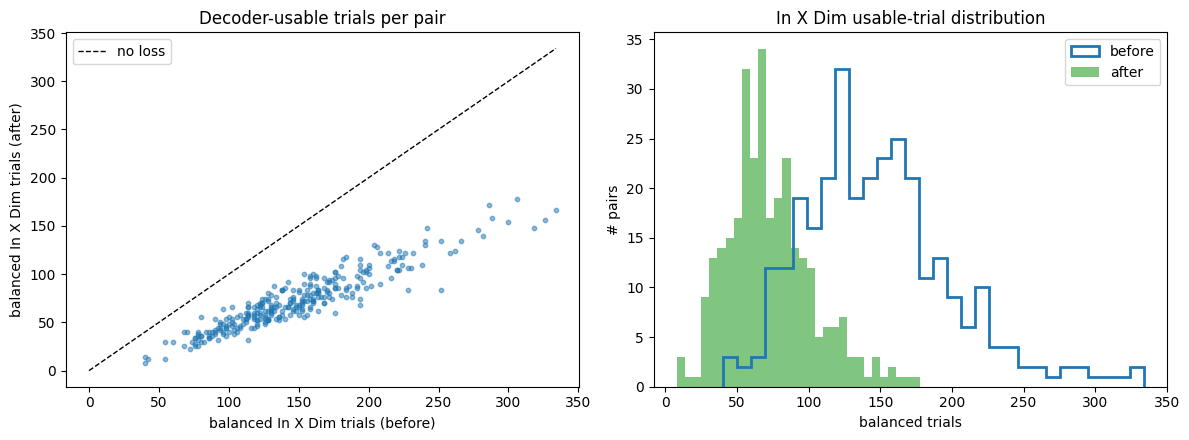

In [15]:
# Decoder-available trials after matching. Method B thins only `In X Dim` (the dispersed
# partitions ARE the target shape, so they are left intact) -> `In X Dim` stays the limiting
# partition. The decode balances the two choice classes (balance_by_filters=True), so the
# usable trial count per pair = 2 * min(Chose, Not Chose). Compare before vs after.

kept = rev.pivot_table(index=["sub", "session", "feat"], columns="choice",
                       values="kept_trials", fill_value=0)
kept.columns = [f"kept_{c}" for c in kept.columns]
orig = (runs_df[runs_df.partition == "In X Dim"]
        .groupby(["sub", "session", "feat", "choice"]).run_length.sum()
        .unstack("choice").fillna(0))
orig.columns = [f"orig_{c}" for c in orig.columns]
ix = orig.join(kept, how="inner")
ix["bal_before"] = 2 * ix[["orig_Chose", "orig_Not Chose"]].min(axis=1)
ix["bal_after"]  = 2 * ix[["kept_Chose", "kept_Not Chose"]].min(axis=1)
ix["retained"]   = ix["bal_after"] / ix["bal_before"]

print("Decoder-usable (class-balanced) In X Dim trials per pair:")
print(ix[["bal_before", "bal_after"]].describe().round(1))
print(f"\nmedian retained fraction of usable trials: {ix.retained.median():.2f} "
      f"(mean {ix.retained.mean():.2f}, min {ix.retained.min():.2f})")
for thr in [10, 20, 40]:
    b = (ix.bal_before >= thr).sum(); a = (ix.bal_after >= thr).sum()
    print(f"  pairs with >= {thr:>2} balanced trials:  before {b:>3}/{len(ix)}   after {a:>3}/{len(ix)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
mx = ix.bal_before.max()
axes[0].scatter(ix.bal_before, ix.bal_after, s=10, alpha=0.5)
axes[0].plot([0, mx], [0, mx], "k--", lw=1, label="no loss")
axes[0].set_xlabel("balanced In X Dim trials (before)")
axes[0].set_ylabel("balanced In X Dim trials (after)")
axes[0].set_title("Decoder-usable trials per pair"); axes[0].legend()
axes[1].hist(ix.bal_before, bins=30, histtype="step", lw=2, label="before")
axes[1].hist(ix.bal_after, bins=30, alpha=0.6, color="C2", label="after")
axes[1].set_xlabel("balanced trials"); axes[1].set_ylabel("# pairs")
axes[1].set_title("In X Dim usable-trial distribution"); axes[1].legend()
plt.tight_layout(); plt.show()

### Conclusion (alternative method)

- **Matching toward the dispersed shape is feasible** in ~100% of pairs. Because subsetting can only *shorten*
  runs (never split or lengthen them), each `In X Dim` run is shortened to a draw from the dispersed target
  distribution. This keeps ~48% of `In X Dim` trials (mean frac kept ≈ 0.48 `Chose`, ≈ 0.46 `Not Chose`).
  Contrast with method A (match toward the blocky shape), feasible in **0%** of pairs — subsampling cannot
  manufacture the long runs / low-frequency power the dispersed partitions lack.

- **It works in the lag domain.** After thinning, `In X Dim`'s slowly-decaying autocorrelation tail collapses
  to ≈0 at lags ≥ 2, landing at or below `Not in X Dim` / `Low`. The low-frequency content that couples to
  slow drift — and that inflates the session-permute shuffle — is removed. (A slight negative lag-1 dip is a
  harmless high-frequency artifact of aggressive shortening.)

- **Why this is the right direction.** Thinning `In X Dim` destroys the block structure the slow-drift confound
  rides on, so its session-permute shuffle drops *toward chance* — equalizing the baselines at the **low** end
  rather than trying (impossibly) to lift everyone to the high end. The within-trial neural↔choice pairing is
  preserved (every kept trial keeps its own firing rate and correct label), so the signal we want survives.

- This makes behavioral subselection the **mirror image of the note's neural-drift-removal complement**: kill
  the low-frequency *choice* power instead of the low-frequency *neural* power. Doing both and showing they
  agree is the strongest version of the result.

- **Cost / caveat.** It roughly halves the already-scarce limiting partition (median class-balanced `In X Dim`
  trials 143 → 68 per pair; the note's "power note" applies), and any *real* decoding that genuinely rode on
  block structure is removed too — but that is the contaminated component, so removing it is a feature here.

- **Variant for all three partitions at once:** thin *every* partition to a common maximally-white target.
  Always feasible, since whitening is the feasible direction for all of them.